# Plant Health — Data Engineering Pipeline

Focused on the 3 model features: `Soil_Moisture`, `Ambient_Temperature`, `Humidity`

## 1. Config & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (12, 5)

# === Same parameters used in train.py ===
FEATURES = ['Soil_Moisture', 'Ambient_Temperature', 'Humidity']
TARGET   = 'Plant_Health_Status'

RF_PARAMS = {
    'n_estimators'    : 300,
    'max_depth'       : 15,
    'min_samples_split': 5,
    'min_samples_leaf': 2,
    'max_features'    : 'sqrt',
    'random_state'    : 42,
}

RAW_PATH   = 'plant_health_data (1).csv'
CLEAN_PATH = 'plant_health_cleaned.csv'
PROC_PATH  = 'plant_health_processed.csv'

## 2. Data Ingestion

In [2]:
df = pd.read_csv(RAW_PATH)
df.columns = df.columns.str.strip()
print(f'Shape: {df.shape}')
df[FEATURES + [TARGET]].head()

Shape: (1200, 14)


,Soil_Moisture,Ambient_Temperature,Humidity,Plant_Health_Status
0,27.521109,22.240245,55.291904,High Stress
1,14.835566,21.706763,63.949181,High Stress
2,17.086362,21.180946,67.837956,High Stress
3,15.336156,22.593302,58.190811,High Stress
4,39.822216,28.929001,63.772036,High Stress


In [84]:
print('Data types:')
print(df[FEATURES + [TARGET]].dtypes)
print(f'\nMemory: {df.memory_usage(deep=True).sum() / 1024:.1f} KB')

Data types:
Soil_Moisture          float64
Ambient_Temperature    float64
Humidity               float64
Plant_Health_Status     object
dtype: object

Memory: 271.2 KB


## 3. EDA — Model Features Only

In [3]:
# Summary stats for model features
df[FEATURES].describe()

,Soil_Moisture,Ambient_Temperature,Humidity
count,1200.000000,1200.000000,1200.000000
mean,25.106918,23.999130,54.853165
std,8.677725,3.441561,8.784916
min,10.000724,18.001993,40.028758
25%,17.131893,21.101766,47.019694
50%,25.168333,23.889044,54.692069
75%,32.370231,27.042634,62.451053
max,39.993164,29.990886,69.968871


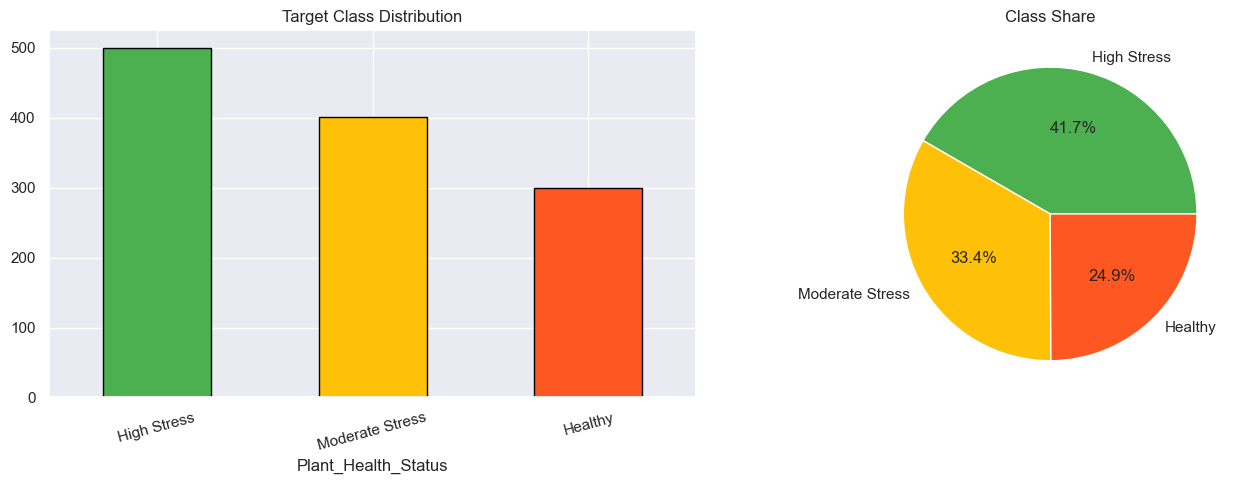

In [ ]:
# Target class distribution
palette = {'Healthy': '#4CAF50', 'Moderate Stress': '#FFC107', 'High Stress': '#FF5722'}
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
counts = df[TARGET].value_counts()
counts.plot(kind='bar', ax=axes[0], color=list(palette.values()), edgecolor='black')
axes[0].set_title('Target Class Distribution')
axes[0].tick_params(axis='x', rotation=15)


counts.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', colors=list(palette.values()))
axes[1].set_title('Class Share')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

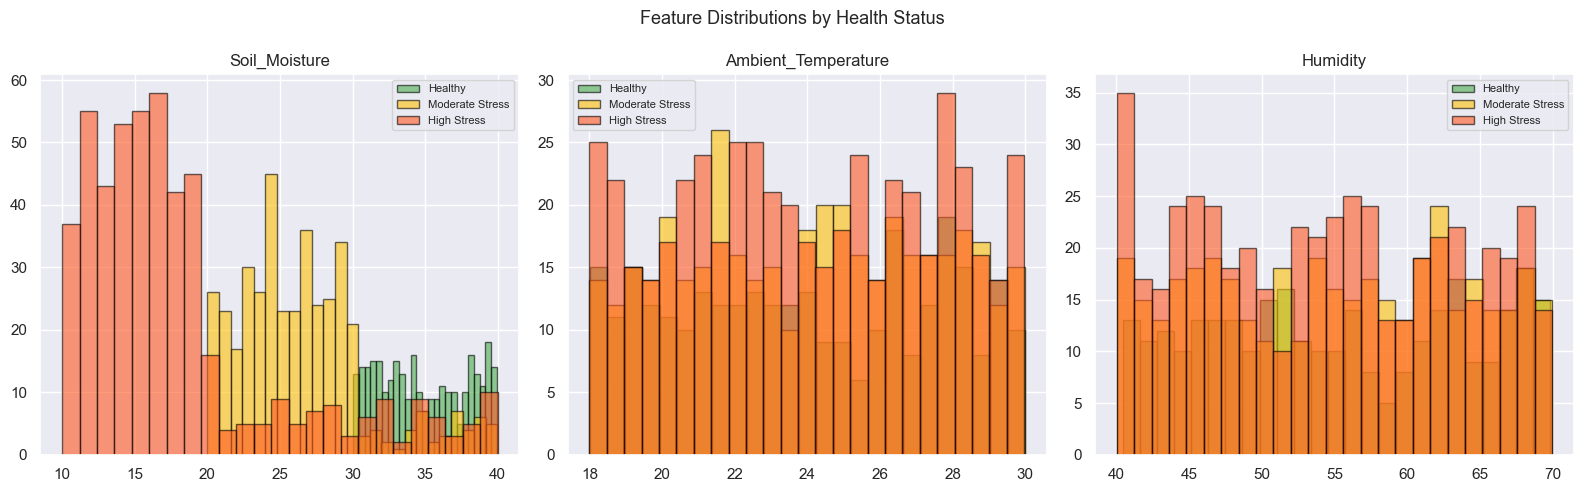

In [86]:
# Distribution of each model feature
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col in zip(axes, FEATURES):
    for label, color in palette.items():
        df[df[TARGET] == label][col].hist(ax=ax, bins=25, alpha=0.6, label=label, color=color, edgecolor='black')
    ax.set_title(col)
    ax.legend(fontsize=8)
plt.suptitle('Feature Distributions by Health Status', fontsize=13)
plt.tight_layout()
plt.show()

In [88]:
# # Pairplot of model features
# sns.pairplot(df[FEATURES + [TARGET]], hue=TARGET, palette=palette, plot_kws={'alpha': 0.5})
# plt.suptitle('Pairplot — Model Features', y=1.01, fontsize=13)
# plt.show()

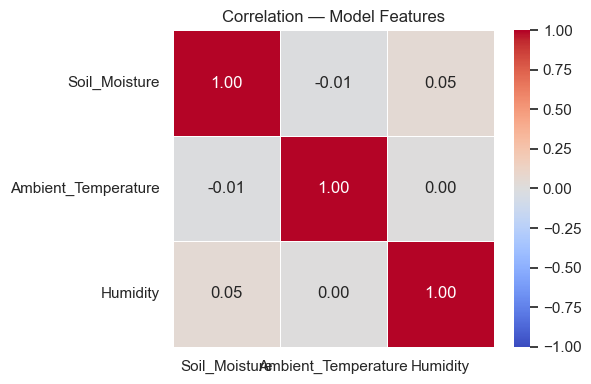

In [9]:
# Correlation among model features
plt.figure(figsize=(6, 4))
sns.heatmap(df[FEATURES].corr(), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation — Model Features')
plt.tight_layout()
plt.show()

## 4. Data Cleaning

In [89]:
print('Missing values in model features:')
print(df[FEATURES + [TARGET]].isnull().sum())

before = len(df)
df = df.drop_duplicates()
print(f'Duplicates removed: {before - len(df)} | Rows remaining: {len(df)}')

Missing values in model features:
Soil_Moisture          0
Ambient_Temperature    0
Humidity               0
Plant_Health_Status    0
dtype: int64
Duplicates removed: 0 | Rows remaining: 1200


<!-- ## 5. Outlier Detection & Treatment (IQR) — Model Features -->

In [91]:
# df_clean = df.copy()
# report = {}

# for col in FEATURES:
#     Q1, Q3 = df_clean[col].quantile([0.25, 0.75])
#     IQR = Q3 - Q1
#     lo, hi = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
#     n_out = ((df_clean[col] < lo) | (df_clean[col] > hi)).sum()
#     report[col] = n_out
#     df_clean[col] = df_clean[col].clip(lo, hi)   # Winsorize

# print('Outliers detected and capped:')
# print(pd.Series(report))

## 6. Feature Engineering on Model Features

In [92]:
# Stress score using the same 3 features from train.py
df_clean['Stress_Score'] = (
    (100 - df_clean['Soil_Moisture'])       * 0.4 +
    df_clean['Ambient_Temperature']          * 0.3 +
    (100 - df_clean['Humidity'])            * 0.3
)
df_clean['Moisture_Humidity'] = df_clean['Soil_Moisture'] * df_clean['Humidity'] / 100

eng_features = FEATURES + ['Stress_Score', 'Moisture_Humidity']
print('All features for analysis:', eng_features)
df_clean[eng_features].describe()

All features for analysis: ['Soil_Moisture', 'Ambient_Temperature', 'Humidity', 'Stress_Score', 'Moisture_Humidity']


,Soil_Moisture,Ambient_Temperature,Humidity,Stress_Score,Moisture_Humidity
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,25.106918,23.999130,54.853165,50.701022,13.812976
std,8.677725,3.441561,8.784916,4.592552,5.401016
min,10.000724,18.001993,40.028758,39.654375,4.283826
25%,17.131893,21.101766,47.019694,47.244677,9.264487
50%,25.168333,23.889044,54.692069,50.726192,13.491160
75%,32.370231,27.042634,62.451053,53.971276,17.771859
max,39.993164,29.990886,69.968871,62.291880,27.762544


In [94]:
# fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# sns.violinplot(data=df_clean, x=TARGET, y='Stress_Score',    palette=palette, ax=axes[0], inner='quartile')
# sns.violinplot(data=df_clean, x=TARGET, y='Moisture_Humidity', palette=palette, ax=axes[1], inner='quartile')
# axes[0].set_title('Stress Score by Health Status')
# axes[1].set_title('Moisture x Humidity by Health Status')
# for ax in axes:
#     ax.set_xlabel('')
#     ax.tick_params(axis='x', rotation=15)
# plt.tight_layout()
# plt.show()

## 7. Data Validation

In [14]:
SCHEMA = {
    'Soil_Moisture'      : (0, 100),
    'Ambient_Temperature': (-10, 60),
    'Humidity'           : (0, 100),
}
for col, (lo, hi) in SCHEMA.items():
    bad = ((df_clean[col] < lo) | (df_clean[col] > hi)).sum()
    print(f'{col}: {bad} violations')

print('\nTarget classes:', df_clean[TARGET].unique().tolist())

Soil_Moisture: 0 violations
Ambient_Temperature: 0 violations
Humidity: 0 violations

Target classes: ['High Stress', 'Moderate Stress', 'Healthy']


## 8. Encoding & Scaling (same as train.py)

In [95]:
le = LabelEncoder()
df_clean['Health_Encoded'] = le.fit_transform(df_clean[TARGET])
print('Label map:', dict(zip(le.transform(le.classes_), le.classes_)))

scaler = StandardScaler()
df_proc = df_clean.copy()
df_proc[eng_features] = scaler.fit_transform(df_clean[eng_features])
df_proc[eng_features].describe().T[['mean','std','min','max']]

Label map: {np.int64(0): 'Healthy', np.int64(1): 'High Stress', np.int64(2): 'Moderate Stress'}


,mean,std,min,max
Soil_Moisture,9.621933e-17,1.000417,-1.741527,1.716170
Ambient_Temperature,-1.190159e-15,1.000417,-1.743290,1.741725
Humidity,1.184238e-16,1.000417,-1.688188,1.721361
Stress_Score,-1.010303e-15,1.000417,-2.406342,2.524890
Moisture_Humidity,-5.921189e-17,1.000417,-1.765061,2.583844


## 9. Model Validation — Confirm 91% Accuracy with Same Parameters

In [96]:
X = df_clean[FEATURES]
y = le.transform(df_clean[TARGET])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(**RF_PARAMS)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy: 0.9125
                 precision    recall  f1-score   support

        Healthy       0.83      0.95      0.89        65
    High Stress       1.00      0.87      0.93        85
Moderate Stress       0.91      0.92      0.92        90

       accuracy                           0.91       240
      macro avg       0.91      0.92      0.91       240
   weighted avg       0.92      0.91      0.91       240



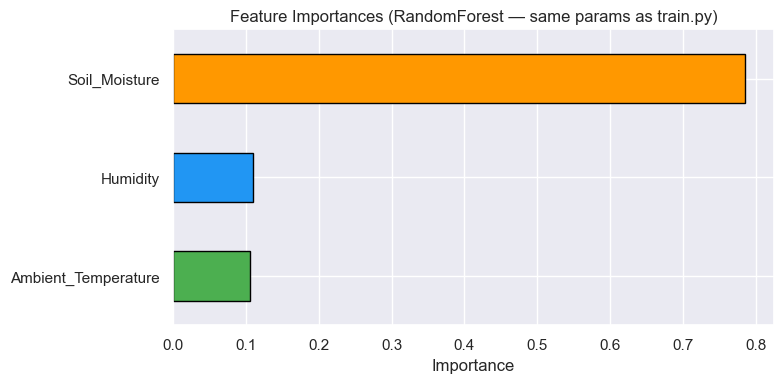

Soil_Moisture          0.785625
Humidity               0.109242
Ambient_Temperature    0.105133
dtype: float64


In [97]:
# Feature importances from the model
imp = pd.Series(model.feature_importances_, index=FEATURES).sort_values(ascending=True)
imp.plot(kind='barh', color=['#4CAF50','#2196F3','#FF9800'], edgecolor='black', figsize=(8, 4))
plt.title('Feature Importances (RandomForest — same params as train.py)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()
print(imp.sort_values(ascending=False))

## 10. Export

In [18]:
df_clean.to_csv(CLEAN_PATH, index=False)
df_proc.to_csv(PROC_PATH, index=False)
print(f'Cleaned  -> {CLEAN_PATH} ({len(df_clean)} rows)')
print(f'Processed-> {PROC_PATH} ({len(df_proc)} rows)')
print('\n=== Pipeline complete ===')
print(f'Features used : {FEATURES}')
print(f'RF params     : {RF_PARAMS}')

Cleaned  -> plant_health_cleaned.csv (1200 rows)
Processed-> plant_health_processed.csv (1200 rows)

=== Pipeline complete ===
Features used : ['Soil_Moisture', 'Ambient_Temperature', 'Humidity']
RF params     : {'n_estimators': 300, 'max_depth': 15, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'random_state': 42}
